In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

print("NumPy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("SciPy:", scipy.__version__)

NumPy: 2.2.6
Matplotlib: 3.10.9
SciPy: 1.15.3


In [2]:
# Image size (camera resolution)

H, W = 480, 640

# Coordinate system (x1, y1 in pixels)
x = np.linspace(0, W - 1, W)
y = np.linspace(0, H - 1, H)
X, Y = np.meshgrid(x, y)

# Fringe / system parameters (chosen for visualization, not realism)
p1 = 40                 # fringe period (pixels)
theta = np.deg2rad(15)  # projection angle
a = 2000                # perspective distance parameter
M = 1.0                 # magnification

# Intensity parameters
A = 1.0   # average intensity
B = 0.9   # modulation


print("Grid and parameters initialized.")

Grid and parameters initialized.


In [3]:
def project(input_phase):
    """Simulate non-telecentric projector applying perspective bias.

    Taylor approximation of Ch.2 Eq. 2-44 expanded for h=0:
        bias(x) = (4*pi/p1) * x^2 * tan(theta) / a
    Note: Ch.4 Eq. 4-2 in the thesis has a typo (missing 2*pi); Eq. 2-44 is correct.
    Uses module-level p1, X, theta, a from the parameters cell.
    """
    bias = (4 * np.pi / p1) * (X**2 * np.tan(theta) / a)
    return input_phase - bias

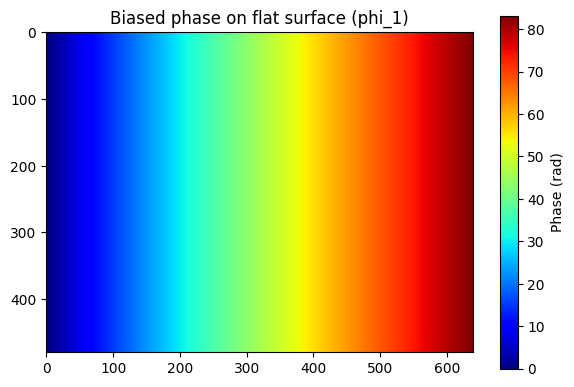

In [4]:
# Biased phase on flat reference surface (phi_1)
phi1 = (2 * np.pi / p1) * X - (4 * np.pi / p1) * (X**2 * np.tan(theta) / a)

# Visualize phase map
plt.figure(figsize=(6, 4))
plt.imshow(phi1, cmap='jet')
plt.colorbar(label='Phase (rad)')
plt.title('Biased phase on flat surface (phi_1)')
plt.tight_layout()
plt.show()

In [5]:
# 4-step phase shifting (common and enough to start)
deltas = np.array([0, np.pi/2, np.pi, 3*np.pi/2])

# Simulate 4 captured intensity images on flat surface
frames_flat = []
for d in deltas:
    I = A + B * np.cos(phi1 + d)
    frames_flat.append(I)

frames_flat = np.stack(frames_flat, axis=-1)  # shape: (H, W, 4)

print("frames_flat shape:", frames_flat.shape)
print("min/max intensity:", frames_flat.min(), frames_flat.max())

frames_flat shape: (480, 640, 4)
min/max intensity: 0.09999999999999998 1.9


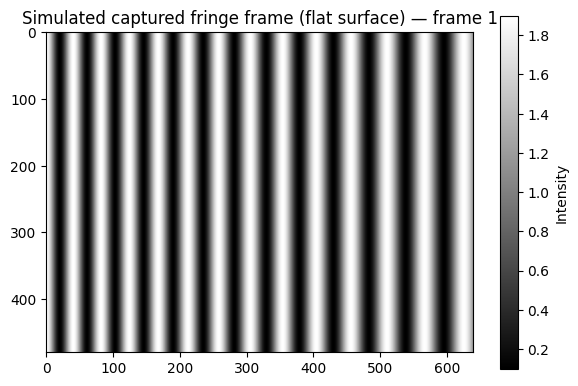

In [6]:
plt.figure(figsize=(6, 4))
plt.imshow(frames_flat[..., 0], cmap='gray')
plt.colorbar(label='Intensity')
plt.title('Simulated captured fringe frame (flat surface) — frame 1')
plt.tight_layout()
plt.show()

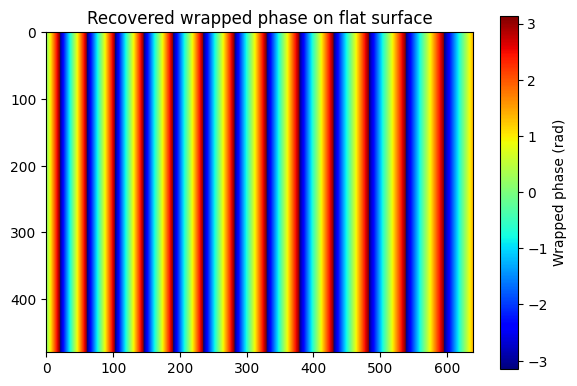

In [7]:
I1 = frames_flat[..., 0]
I2 = frames_flat[..., 1]
I3 = frames_flat[..., 2]
I4 = frames_flat[..., 3]

phi1_wrapped = np.arctan2(I4 - I2, I1 - I3)

plt.figure(figsize=(6, 4))
plt.imshow(phi1_wrapped, cmap='jet')
plt.colorbar(label='Wrapped phase (rad)')
plt.title('Recovered wrapped phase on flat surface')
plt.tight_layout()
plt.show()

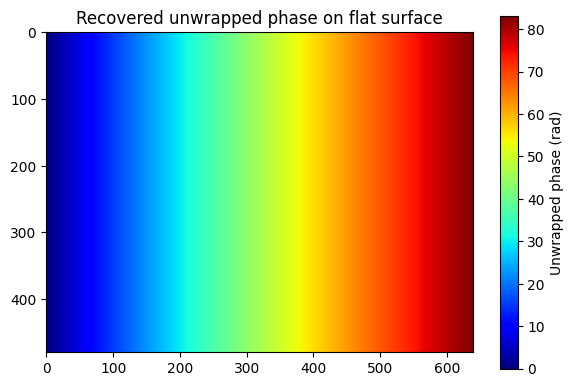

In [8]:
phi1_unwrapped = np.unwrap(np.unwrap(phi1_wrapped, axis=1), axis=0)

plt.figure(figsize=(6, 4))
plt.imshow(phi1_unwrapped, cmap='jet')
plt.colorbar(label='Unwrapped phase (rad)')
plt.title('Recovered unwrapped phase on flat surface')
plt.tight_layout()
plt.show()

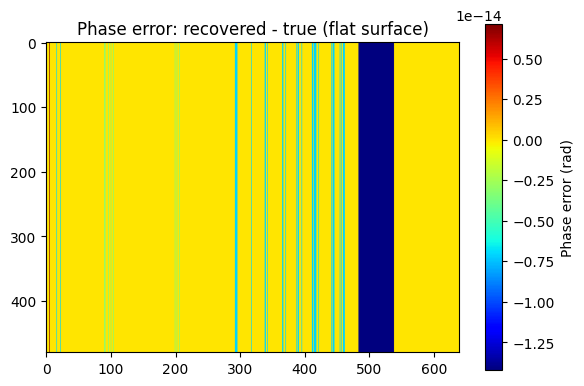

Error stats (rad): mean = -1.6209256159527285e-15 std = 4.191352922530645e-15 max abs = 1.4210854715202004e-14


In [9]:
# Remove global offset for comparison
phi1_true0 = phi1 - np.mean(phi1)
phi1_rec0  = phi1_unwrapped - np.mean(phi1_unwrapped)

error = phi1_rec0 - phi1_true0

plt.figure(figsize=(6, 4))
plt.imshow(error, cmap='jet')
plt.colorbar(label='Phase error (rad)')
plt.title('Phase error: recovered - true (flat surface)')
plt.tight_layout()
plt.show()

print("Error stats (rad): mean =", error.mean(), "std =", error.std(), "max abs =", np.max(np.abs(error)))

In [10]:
# 1D profile of phase vs x (average across rows)
phi1_profile = phi1_unwrapped.mean(axis=0)   # shape (W,)

# Fit a straight line: tilt(x) = m*x + c
m, c = np.polyfit(x, phi1_profile, 1)
tilt_1d = m * x + c

# Expand back to 2D so we can subtract from the whole phase map
tilt_2d = np.tile(tilt_1d, (H, 1))

# Bias (curvature) term = measured phase - tilt
bias_2d = phi1_unwrapped - tilt_2d

print("Tilt slope m (rad/pixel):", m)

Tilt slope m (rad/pixel): 0.13018453117695158


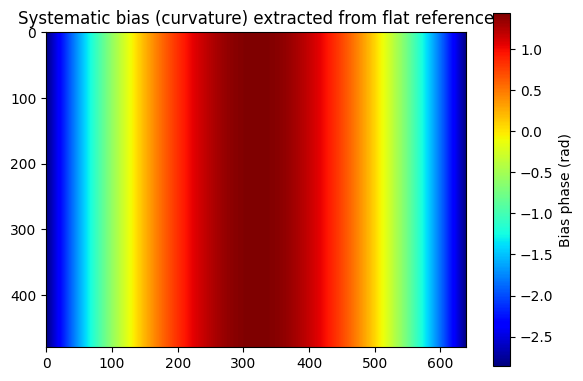

In [11]:
plt.figure(figsize=(6, 4))
plt.imshow(bias_2d, cmap='jet')
plt.colorbar(label='Bias phase (rad)')
plt.title('Systematic bias (curvature) extracted from flat reference')
plt.tight_layout()
plt.show()

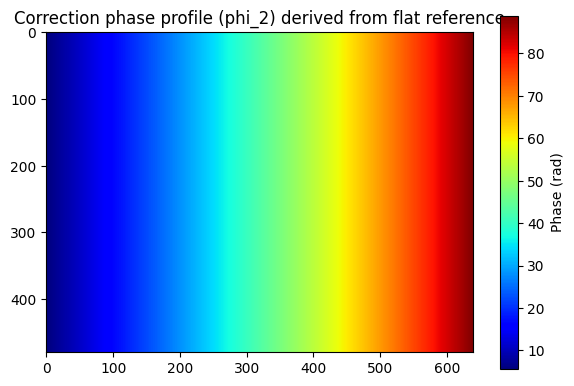

In [12]:
phi2 = tilt_2d - bias_2d   # same as: phi2 = 2*tilt_2d - phi1_unwrapped

plt.figure(figsize=(6, 4))
plt.imshow(phi2, cmap='jet')
plt.colorbar(label='Phase (rad)')
plt.title('Correction phase profile (phi_2) derived from flat reference')
plt.tight_layout()
plt.show()

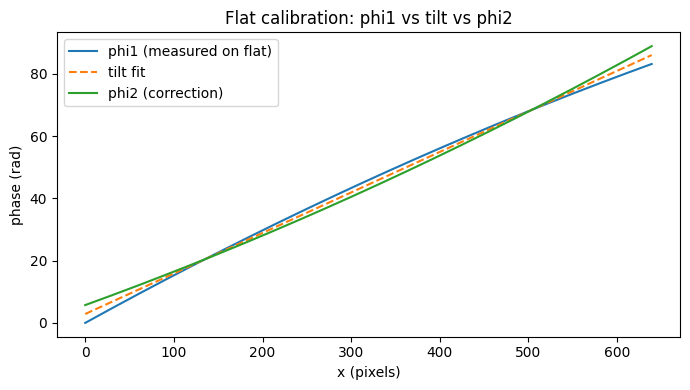

In [13]:
phi2_profile = phi2.mean(axis=0)

plt.figure(figsize=(7,4))
plt.plot(x, phi1_profile, label='phi1 (measured on flat)')
plt.plot(x, tilt_1d, '--', label='tilt fit')
plt.plot(x, phi2_profile, label='phi2 (correction)')
plt.xlabel('x (pixels)')
plt.ylabel('phase (rad)')
plt.title('Flat calibration: phi1 vs tilt vs phi2')
plt.legend()
plt.tight_layout()
plt.show()

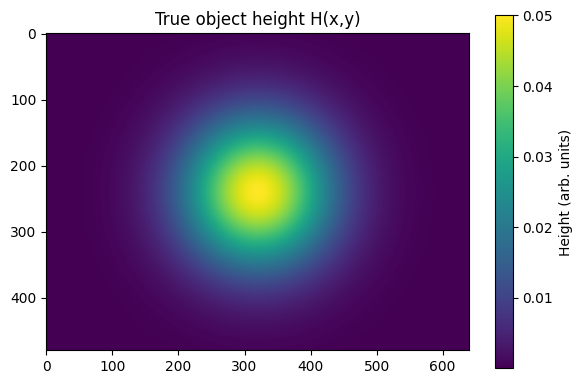

In [14]:
# Object height map H(x,y)
H_obj = 0.05 * np.exp(-((X - W/2)**2 + (Y - H/2)**2) / (2 * (80**2)))

plt.figure(figsize=(6,4))
plt.imshow(H_obj, cmap='viridis')
plt.colorbar(label='Height (arb. units)')
plt.title('True object height H(x,y)')
plt.tight_layout()
plt.show()

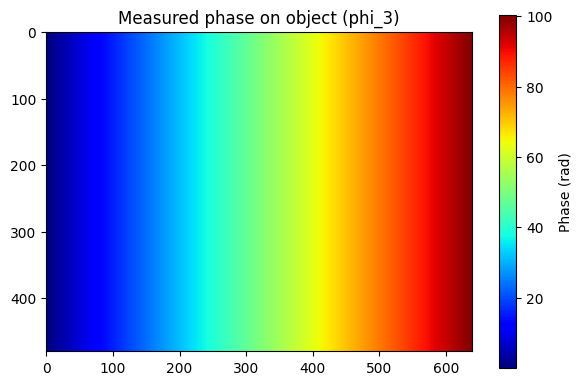

In [15]:
# Height-to-phase sensitivity
K = (4 * np.pi * np.sin(theta)) / (p1 * M)

# Measured phase on object (after calibration)
phi3 = (2 * np.pi / p1) * X + K * H_obj

plt.figure(figsize=(6,4))
plt.imshow(phi3, cmap='jet')
plt.colorbar(label='Phase (rad)')
plt.title('Measured phase on object (phi_3)')
plt.tight_layout()
plt.show()

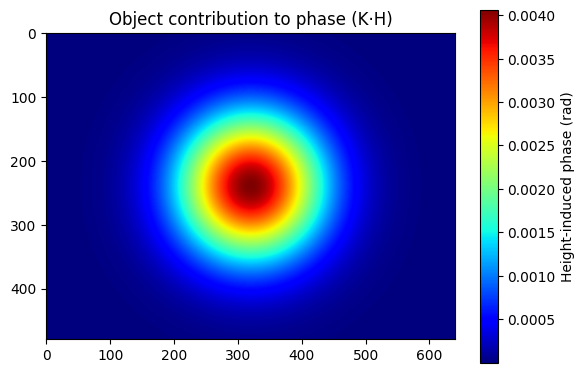

min/max height phase: 1.5150783203584933e-08 0.00406552005351557


In [16]:
carrier = (2 * np.pi / p1) * X
height_phase = phi3 - carrier   # should be K * H_obj

plt.figure(figsize=(6,4))
plt.imshow(height_phase, cmap='jet')
plt.colorbar(label='Height-induced phase (rad)')
plt.title('Object contribution to phase (K·H)')
plt.tight_layout()
plt.show()

print("min/max height phase:", height_phase.min(), height_phase.max())

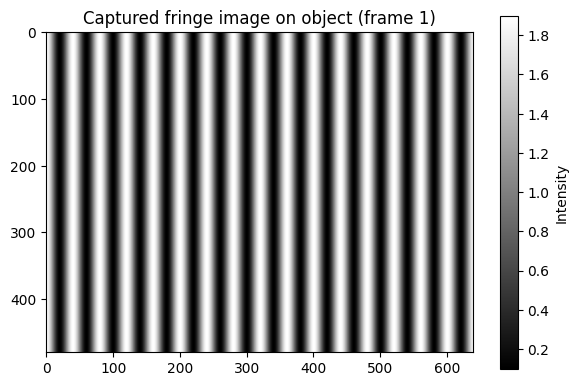

In [17]:
frames_obj = []
for d in deltas:
    I = A + B * np.cos(phi3 + d)
    frames_obj.append(I)

frames_obj = np.stack(frames_obj, axis=-1)

plt.figure(figsize=(6,4))
plt.imshow(frames_obj[..., 0], cmap='gray')
plt.colorbar(label='Intensity')
plt.title('Captured fringe image on object (frame 1)')
plt.tight_layout()
plt.show()

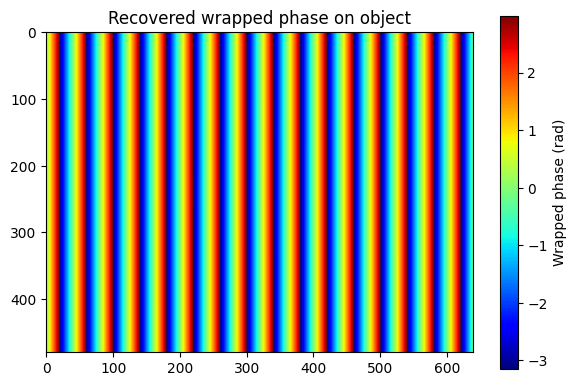

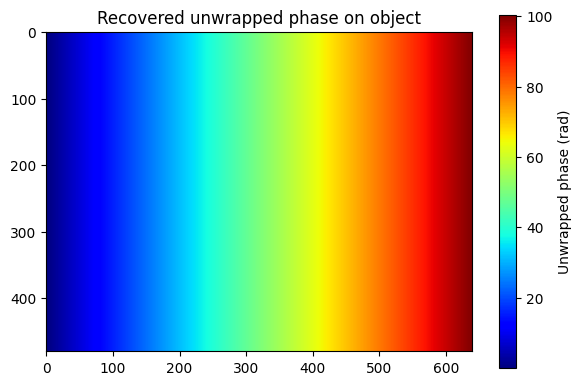

phi3_unwrapped min/max: 1.5150782912205013e-08 100.373886715837


In [18]:
# --- Cell 16: Recover phase on the object using 4-step PSI ---

I1 = frames_obj[..., 0]
I2 = frames_obj[..., 1]
I3 = frames_obj[..., 2]
I4 = frames_obj[..., 3]

phi3_wrapped = np.arctan2(I4 - I2, I1 - I3)
phi3_unwrapped = np.unwrap(np.unwrap(phi3_wrapped, axis=1), axis=0)

# Plot wrapped phase
plt.figure(figsize=(6,4))
plt.imshow(phi3_wrapped, cmap='jet')
plt.colorbar(label='Wrapped phase (rad)')
plt.title('Recovered wrapped phase on object')
plt.tight_layout()
plt.show()

# Plot unwrapped phase
plt.figure(figsize=(6,4))
plt.imshow(phi3_unwrapped, cmap='jet')
plt.colorbar(label='Unwrapped phase (rad)')
plt.title('Recovered unwrapped phase on object')
plt.tight_layout()
plt.show()

print("phi3_unwrapped min/max:", phi3_unwrapped.min(), phi3_unwrapped.max())

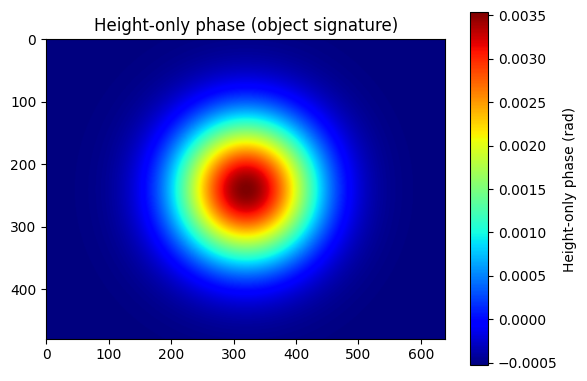

height-phase min/max: -0.0005331699675945763 0.003534811414924716


In [19]:
# Remove tilt estimated from object phase (best practice)
phi3_profile = phi3_unwrapped.mean(axis=0)
m3, c3 = np.polyfit(x, phi3_profile, 1)
tilt3_2d = np.tile(m3*x + c3, (H, 1))

phi_height = phi3_unwrapped - tilt3_2d
phi_height -= phi_height.mean()  # remove constant offset

plt.figure(figsize=(6,4))
plt.imshow(phi_height, cmap='jet')
plt.colorbar(label='Height-only phase (rad)')
plt.title('Height-only phase (object signature)')
plt.tight_layout()
plt.show()

print("height-phase min/max:", phi_height.min(), phi_height.max())

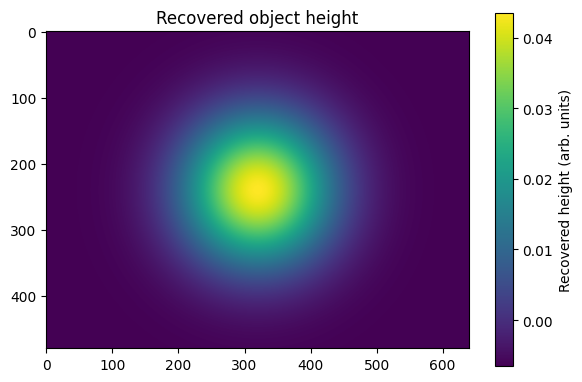

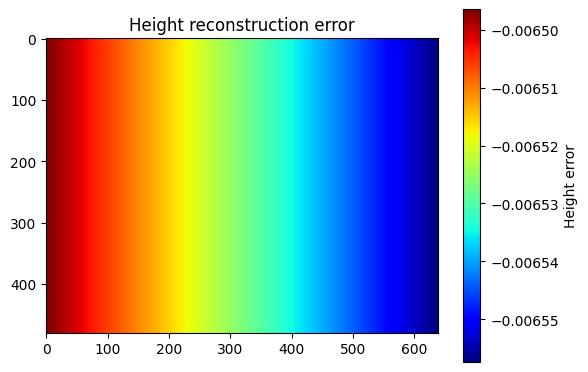

Height error stats:
mean: -0.006526898757812155
std : 1.7645046580428724e-05
max : 0.006557413158898793


In [20]:
lambda_eq = (p1 * M) / (4 * np.pi * np.sin(theta))

H_rec = lambda_eq * phi_height  # phi_height is after tilt removal and mean centering

# Plot recovered height
plt.figure(figsize=(6,4))
plt.imshow(H_rec, cmap='viridis')
plt.colorbar(label='Recovered height (arb. units)')
plt.title('Recovered object height')
plt.tight_layout()
plt.show()

# Error vs true object
err_H = H_rec - H_obj

plt.figure(figsize=(6,4))
plt.imshow(err_H, cmap='jet')
plt.colorbar(label='Height error')
plt.title('Height reconstruction error')
plt.tight_layout()
plt.show()

print("Height error stats:")
print("mean:", err_H.mean())
print("std :", err_H.std())
print("max :", np.max(np.abs(err_H)))

In [21]:
H_rec0 = H_rec - H_rec.mean() + H_obj.mean()
err_H0 = H_rec0 - H_obj

print("After DC alignment:")
print("mean:", err_H0.mean())
print("std :", err_H0.std())
print("max :", np.max(np.abs(err_H0)))

After DC alignment:
mean: 1.8122156968779455e-18
std : 1.7645046580428724e-05
max : 3.0514401172785438e-05


## Stage 1 — Close the Simulation Loop

Until now the notebook wrote `phi1` and `phi3` analytically. To validate the inverse-grating method, we close the loop by routing the *intended* projected phase through the biased projector model `project()` (defined in the parameters section) and checking that:

1. Projecting a uniform carrier `(2π/p1)·X` reproduces the analytical `phi1` (forward model is consistent).
2. Projecting the inverse pattern `phi2` (derived from the tilt-flip trick on the flat reference) cancels the curvature term — what comes out is a clean linear ramp in X.

If both hold, the inverse-grating correction is validated end-to-end in simulation before any hardware is touched.

In [22]:
# Stage 1.2 — Validate the forward model against the analytical phi1
# Project a uniform carrier through the biased projector and confirm it matches phi1.

uniform_phase = (2 * np.pi / p1) * X
phi1_simulated = project(uniform_phase)

match = np.allclose(phi1_simulated, phi1)
diff = phi1_simulated - phi1

print("project(uniform) matches analytical phi1?", match)
print("  max |diff|:", np.max(np.abs(diff)))
print("  std diff  :", diff.std())

project(uniform) matches analytical phi1? True
  max |diff|: 0.0
  std diff  : 0.0


Residual = project(phi2) - (2*pi/p1)*X
  std    : 9.937840087943837
  max abs: 28.652248134037222

Original projector bias (for comparison):
  std    : 5.132379295984026
  max abs: 17.185969860121784

After removing best-fit linear ramp from project(phi2):
  nonlinear residual std    : 9.57492124094827e-15
  nonlinear residual max abs: 4.973799150320701e-14

Curvature suppression factor (orig bias std / nonlinear residual std): 536023134481232.7


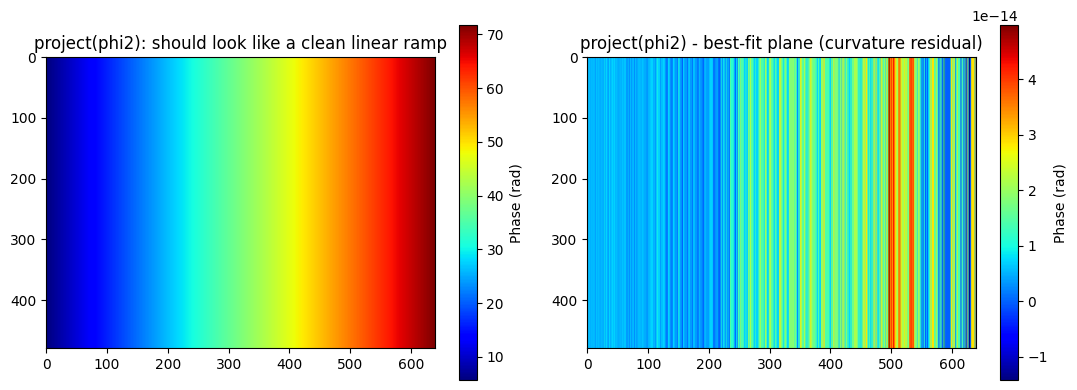

In [23]:
# Stage 1.3 — Validate that the inverse pattern phi2 cancels the projector bias.
# When phi2 is projected through the biased system, the quadratic curvature
# should disappear. What remains should be (at worst) a pure linear ramp,
# which the downstream tilt-removal step in the pipeline handles.

result = project(phi2)
expected_carrier = (2 * np.pi / p1) * X
residual = result - expected_carrier

# Reference: the original projector bias magnitude (what we are trying to cancel)
true_bias = (4 * np.pi / p1) * (X**2 * np.tan(theta) / a)

# Check 1: residual relative to the ideal uniform carrier
print("Residual = project(phi2) - (2*pi/p1)*X")
print("  std    :", residual.std())
print("  max abs:", np.max(np.abs(residual)))
print()
print("Original projector bias (for comparison):")
print("  std    :", true_bias.std())
print("  max abs:", np.max(np.abs(true_bias)))

# Check 2: confirm the curvature is killed (residual is essentially linear in X)
# Fit a plane to the residual and look at what is left after removing it.
res_profile = result.mean(axis=0)
m_res, c_res = np.polyfit(x, res_profile, 1)
linear_part = (m_res * X + c_res)
nonlinear_residual = result - linear_part

print()
print("After removing best-fit linear ramp from project(phi2):")
print("  nonlinear residual std    :", nonlinear_residual.std())
print("  nonlinear residual max abs:", np.max(np.abs(nonlinear_residual)))
print()
print("Curvature suppression factor (orig bias std / nonlinear residual std):",
      true_bias.std() / nonlinear_residual.std() if nonlinear_residual.std() > 0 else float('inf'))

# Visual confirmation
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(result, cmap='jet')
axes[0].set_title('project(phi2): should look like a clean linear ramp')
plt.colorbar(im0, ax=axes[0], label='Phase (rad)')
im1 = axes[1].imshow(nonlinear_residual, cmap='jet')
axes[1].set_title('project(phi2) - best-fit plane (curvature residual)')
plt.colorbar(im1, ax=axes[1], label='Phase (rad)')
plt.tight_layout()
plt.show()